## 1. Libraries & Configuration

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

## 2. Dataset Importation

In [147]:
# %%
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"

df = pd.read_csv(url)

## 3. Data cleaning & Data Quality 

### 3.1. Initial Checking

In [148]:
# Target analsyis:
# - There is no null values
# - There is no change in the definition during the time
# - 37.04 % of canceling

target = "is_canceled"

summary = df[target].value_counts().to_frame("Total")
summary["%"] = df[target].value_counts(normalize=True).round(4)
summary

,Total,%
is_canceled,,
0,75166,0.6296
1,44224,0.3704


In [149]:
df.head(2).T

,0,1
hotel,Resort Hotel,Resort Hotel
is_canceled,0,0
lead_time,342,737
arrival_date_year,2015,2015
arrival_date_month,July,July
arrival_date_week_number,27,27
arrival_date_day_of_month,1,1
stays_in_weekend_nights,0,0
stays_in_week_nights,0,0
adults,2,2


In [150]:
# Checking types of columns:
# - agent and company -> must be categorical columns
# - reservation_status_date -> must be date type

df["agent"] = df["agent"].astype("string")
df["company"] = df["company"].astype("string")

df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])

df.dtypes

hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                 float64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type  

In [151]:
# Standarizing dataset
# - Columns and categorical columns with string normalization

df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

df = df.drop("reservation_status", axis=1)
df = df.drop("reservation_status_date", axis=1)

categorical_columns = list(df.dtypes[df.dtypes == "object"].index)
numerical_columns = list(df.dtypes[df.dtypes != "object"].index)

for col in categorical_columns:
    df[col] = df[col].str.lower().str.strip().str.replace(" ", "_")

### 3.2. Duplicated values

In [152]:
df.duplicated().sum()

32252

In [153]:

print(f"Taxa de cancelamento [DF Original] = {df["is_canceled"].mean():.4f}")
print(f"Taxa de cancelamento [DF sem Duplicatas] = {df[~df.duplicated()]["is_canceled"].mean():.4f}")
print(f"Taxa de cancelamento [DF apenas Duplicatas] = {df[df.duplicated()]["is_canceled"].mean():.4f}")

Taxa de cancelamento [DF Original] = 0.3704
Taxa de cancelamento [DF sem Duplicatas] = 0.2728
Taxa de cancelamento [DF apenas Duplicatas] = 0.6343


In [154]:
dup_flag = df.duplicated(keep="first")

for col in ["market_segment", "customer_type", "deposit_type"]:
    print(f"===== {col} =====")
    print(pd.crosstab(dup_flag, df[col], normalize="index").round(3).T)
    print()

===== market_segment =====
row_0           False  True 
market_segment              
aviation        0.003  0.000
complementary   0.008  0.001
corporate       0.048  0.034
direct          0.135  0.025
groups          0.056  0.463
offline_ta/to   0.159  0.322
online_ta       0.591  0.154
undefined       0.000  0.000

===== customer_type =====
row_0            False  True 
customer_type                
contract         0.036  0.029
group            0.006  0.001
transient        0.825  0.551
transient-party  0.133  0.419

===== deposit_type =====
row_0         False  True 
deposit_type              
no_deposit    0.987  0.578
non_refund    0.012  0.421
refundable    0.001  0.002



### 3.3. NULL values

In [155]:
# Checking null values
# - children: 4
# - country: 488
# - agent: 16.340
# - company: 112.593

nulls = pd.DataFrame({
    "Nulls": df.isnull().sum(),
    "% of total": df.isnull().sum() / len(df) * 100
})
nulls["% of total"] = nulls["% of total"].round(3)

nulls[nulls["% of total"] > 0].sort_values(by="% of total", ascending=False)


,Nulls,% of total
company,112593,94.307
agent,16340,13.686
country,488,0.409
children,4,0.003


In [156]:
null_col = ["children", "country", "agent", "company"]

for col in null_col:
    print(f"Coluna: {col} | Valores únicos = {df[col].nunique()}")
    df_temp = df[col].value_counts(dropna=False).head(5).to_frame("Total")
    df_temp["%"] = (df[col].value_counts(normalize=True, dropna=False).head(5)).round(4)
    display(df_temp)
    print()

Coluna: children | Valores únicos = 5


,Total,%
children,,
0.0,110796,0.9280
1.0,4861,0.0407
2.0,3652,0.0306
3.0,76,0.0006
NaN,4,0.0000



Coluna: country | Valores únicos = 177


,Total,%
country,,
prt,48590,0.4070
gbr,12129,0.1016
fra,10415,0.0872
esp,8568,0.0718
deu,7287,0.0610



Coluna: agent | Valores únicos = 333


,Total,%
agent,,
9.0,31961,0.2677
<NA>,16340,0.1369
240.0,13922,0.1166
1.0,7191,0.0602
14.0,3640,0.0305



Coluna: company | Valores únicos = 352


,Total,%
company,,
<NA>,112593,0.9431
40.0,927,0.0078
223.0,784,0.0066
67.0,267,0.0022
45.0,250,0.0021


In [157]:
# - children: 4 -> Input of mode, it is very low percentual (4/119.000) ~0.003%
# - country: 488 -> Input "unknown", it is a information.
# - agent: 16.340 -> Input "no_agency", it is a information.
# - company: 112.593 -> Input "no_company", it is a information.

mode = df["children"].mode()[0]

df["children"] = df["children"].fillna(mode)
df["country"] = df["country"].fillna("unknown")
df["agent"] = df["agent"].fillna("no_agency")
df["company"] = df["company"].fillna("no_company")

df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

### 3.4. Outliers

In [158]:
# Outliers and wrong informations
# - Apparently there's nothing catching attention

df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119390.0,0.103886,0.398555,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [159]:
# display(df[df["adr"] < 0])
# display(df[df["adr"] > 500])
# display(df[df["adults"] > 5])
# display(df[df["adults"] <= 0])
# display(df[df["adults"] + df["children"] + df["babies"] <= 0])

print(f"Condição = ADR menor que 0         | Total de eventos = {len(df[df["adr"] < 0]):<3} | Taxa Cancelamento = {df[df["adr"] < 0]["is_canceled"].mean():.4f}")
print(f"Condição = ADR acima que 500       | Total de eventos = {len(df[df["adr"] > 500]):<3} | Taxa Cancelamento = {df[df["adr"] > 500]["is_canceled"].mean():.4f}")
print(f"Condição = Adultos na reserva > 5  | Total de eventos = {len(df[df["adults"] > 5]):<3} | Taxa Cancelamento = {df[df["adults"] > 5]["is_canceled"].mean():.4f}")
print(f"Condição = Adultos na reserva = 0  | Total de eventos = {len(df[df["adults"] <= 0]):<3} | Taxa Cancelamento = {df[df["adults"] <= 0]["is_canceled"].mean():.4f}")
print(f"Condição = Pessoas na reserva = 0  | Total de eventos = {len(df[df["adults"] + df["children"] + df["babies"] <= 0]):<3} | Taxa Cancelamento = {df[df["adults"] + df["children"] + df["babies"] <= 0]["is_canceled"].mean():.4f}")

Condição = ADR menor que 0         | Total de eventos = 1   | Taxa Cancelamento = 0.0000
Condição = ADR acima que 500       | Total de eventos = 3   | Taxa Cancelamento = 0.3333
Condição = Adultos na reserva > 5  | Total de eventos = 14  | Taxa Cancelamento = 1.0000
Condição = Adultos na reserva = 0  | Total de eventos = 403 | Taxa Cancelamento = 0.2705
Condição = Pessoas na reserva = 0  | Total de eventos = 180 | Taxa Cancelamento = 0.1389


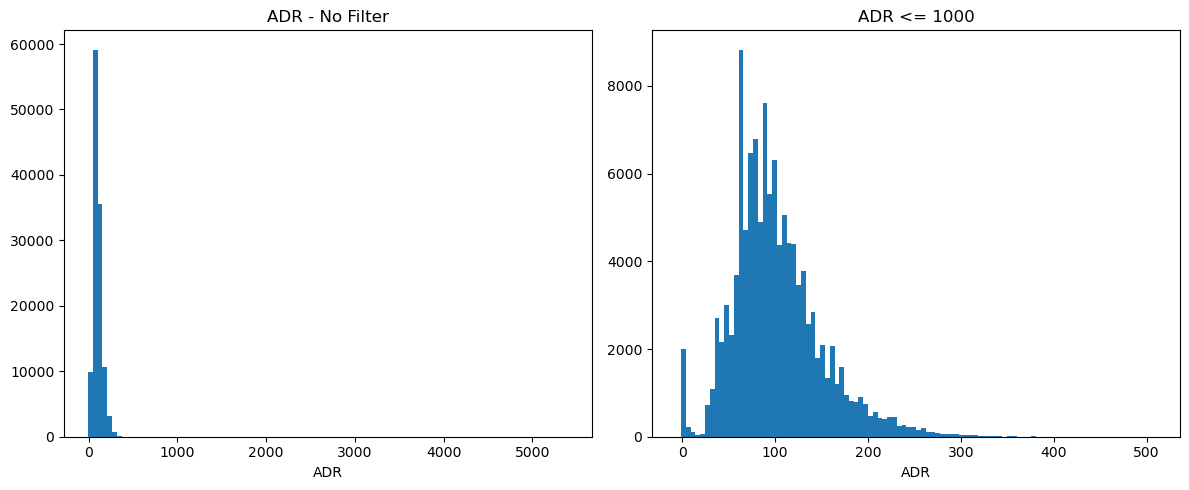

In [160]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["adr"], bins=100)
axes[0].set_title("ADR - No Filter")
axes[0].set_xlabel("ADR")

axes[1].hist(df[(df["adr"] <= 1000)]["adr"], bins=100)
axes[1].set_title("ADR <= 1000")
axes[1].set_xlabel("ADR")

plt.tight_layout()

plt.savefig("images/section_03_histogram_01_adr.jpeg")
plt.show()

In [161]:
# ADR Corrections

df["adr"] = df["adr"].abs()
df["adr"] = df["adr"].clip(upper=500)

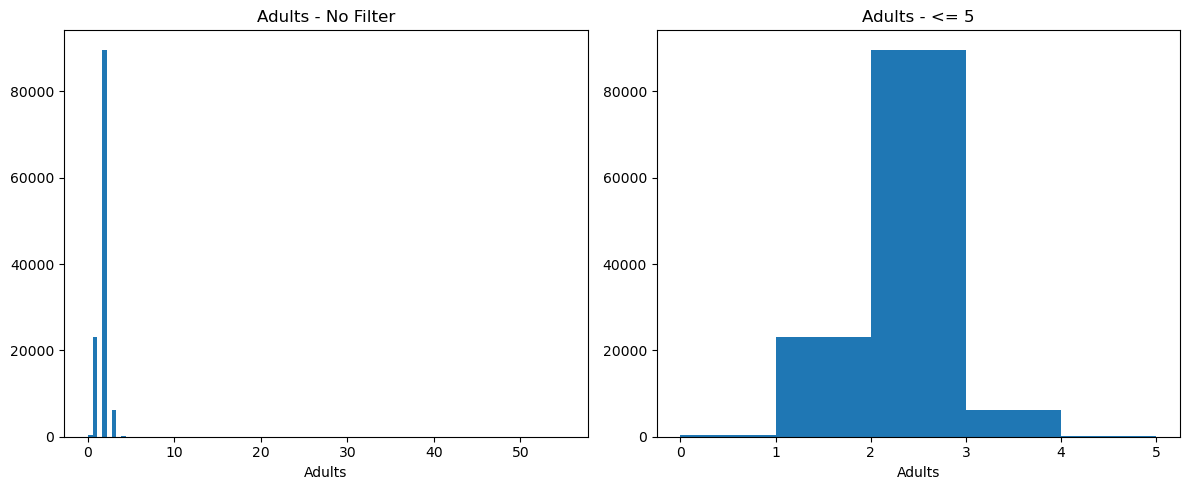

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["adults"], bins=100)
axes[0].set_title("Adults - No Filter")
axes[0].set_xlabel("Adults")

axes[1].hist(df[(df["adults"] <= 5)]["adults"], bins=5)
axes[1].set_title("Adults - <= 5")
axes[1].set_xlabel("Adults")

plt.tight_layout()

plt.savefig("images/section_03_histogram_02_adults.jpeg")
plt.show()

In [166]:
mask = df["adults"] > 5
df = df[~mask].reset_index(drop=True)

mask = mask = df["adults"] == 0
df = df[~mask].reset_index(drop=True)

### 3.5. Target Check

C:\Users\bruno\AppData\Local\Temp\ipykernel_16752\3807671324.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date=pd.to_datetime(


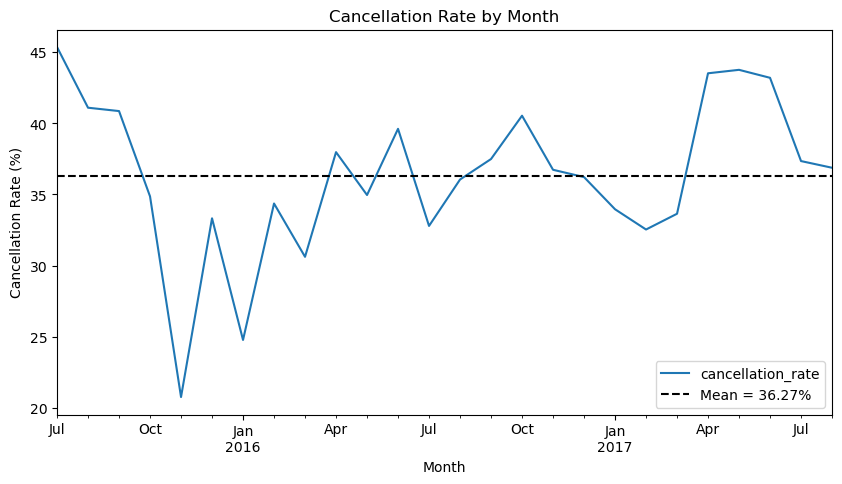

In [164]:
# Checking % cancelation by month:
# - There is some sazonality pherraps, but it is stable during the period
df_plot = (
    df.assign(
        date=pd.to_datetime(
            df["arrival_date_year"].astype(str) + "-" +
            df["arrival_date_month"] + "-01"
        )
    )
    .groupby("date")["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="cancellation_rate")
)

df_plot.plot(
    x="date",
    y="cancellation_rate",
    figsize=(10, 5)
)

m = df_plot["cancellation_rate"].mean()
plt.axhline(
    m,
    linestyle="--",
    label=f"Mean = {m.round(2)}%",
    color="black"
)

plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")
plt.title("Cancellation Rate by Month")
plt.legend()

plt.savefig("images/section_03_histogram_03_cancellation_rate.jpeg")
plt.show()